# 545 Project: what drives pricing for Airbnb in New York City.

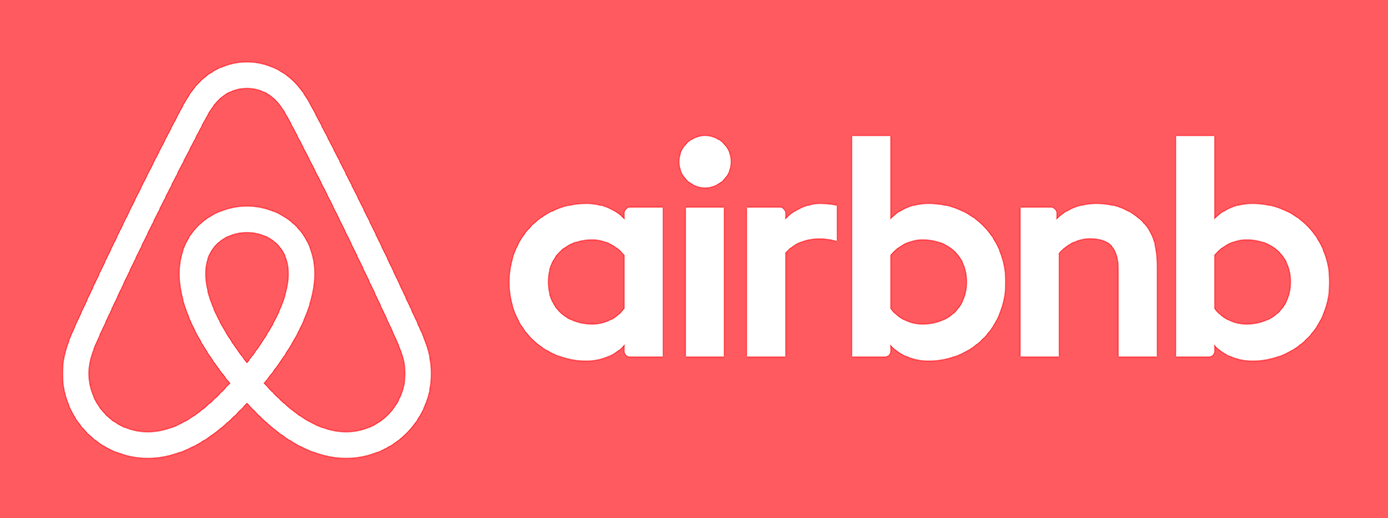


The goal of our project is to understand what drives pricing for Airbnb listings in New York City. Specifically, we aim to model listing prices based on various host, listing, and location attributes, while also investigating what affects availability and review frequency.

Our project seeks to answer questions such as:


*   What makes certain listings more expensive?
*   Do booking features like “instant bookable” or others correlate with higher prices or more frequent reviews?
*  Are there significant pricing differences between neighborhoods after controlling for room type and other variables?

This project is interesting and meaningful because understanding these dynamics could offer value to a variety of stakeholders. For instance, hosts can use our insights to better price their properties and optimize their offe
rings to increase visibility and bookings. Tourists or users can learn which neighborhoods offer better deals or higher-rated stays. Finally, the analysis could help Airbnb itself understand how users interact with listings based on host behavior and listing characteristics.

Group Member:

Lesley Zhao | lesleyzh@seas.upenn.edu

Jianing Cai | cjianing@seas.upenn.edu

## Dependencies

Import the dataset from Kaggle and import all these dependencies to proceed.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arianazmoudeh/airbnbopendata")

print("Path to dataset files:", path)

100%|██████████| 10.5M/10.5M [00:01<00:00, 7.15MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arianazmoudeh/airbnbopendata/versions/1


In [ ]:
import os

# List files in the downloaded dataset directory
print(os.listdir(path))

['Airbnb_Open_Data.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
!pip install geopandas
!pip install contextily
import geopandas as gpd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import contextily as ctx
from shapely.geometry import Point
import plotly.express as px
from collections import defaultdict
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
!pip install xgboost
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 104.3 MB/s eta 0:00:00


## EDA


We will do the initial cleaning and data exploration in this part. For cleaning the dataset, we aim to:


*   Drop duplicate rows
*   Deal with NaN values in each columns
  * Drop columns that are not useful for our analysis
  * Drop columns with too many NaNs
  * Fill NaN values with median or mean, depending on the scenarios

*   Convert data types into more standard forms







In [ ]:
# Load the dataset
file_path = os.path.join(path, "Airbnb_Open_Data.csv")
df = pd.read_csv(file_path)

# Initial inspection
print("Shape:", df.shape)
df.head()

Shape: (102599, 26)


<ipython-input-4-bea1440deb3b>:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [ ]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Convert column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [ ]:
# Data types & missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102058 non-null  int64  
 1   name                            101808 non-null  object 
 2   host_id                         102058 non-null  int64  
 3   host_identity_verified          101769 non-null  object 
 4   host_name                       101654 non-null  object 
 5   neighbourhood_group             102029 non-null  object 
 6   neighbourhood                   102042 non-null  object 
 7   lat                             102050 non-null  float64
 8   long                            102050 non-null  float64
 9   country                         101526 non-null  object 
 10  country_code                    101927 non-null  object 
 11  instant_bookable                101953 non-null  object 
 12  cancellation_policy  

In [ ]:
# Check the percentage of missing values in each column.
# This can help us decide which column to drop and which column to be filled with median or mean.
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print("Missing values (%):\n", missing_pct[missing_pct > 0])

Missing values (%):
 license                           99.998040
house_rules                       50.796606
last_review                       15.512748
reviews_per_month                 15.499030
country                            0.521272
availability_365                   0.438966
host_name                          0.395853
minimum_nights                     0.391934
calculated_host_listings_count     0.312567
review_rate_number                 0.312567
host_identity_verified             0.283172
service_fee                        0.267495
name                               0.244959
price                              0.242019
construction_year                  0.209685
number_of_reviews                  0.179310
country_code                       0.128358
instant_bookable                   0.102883
cancellation_policy                0.074467
neighbourhood_group                0.028415
neighbourhood                      0.015677
long                               0.007839
lat        

In [ ]:
# Summary stats
print(df.describe())

                 id       host_id            lat           long  \
count  1.020580e+05  1.020580e+05  102050.000000  102050.000000   
mean   2.918438e+07  4.926738e+10      40.728097     -73.949652   
std    1.627173e+07  2.853742e+10       0.055852       0.049502   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.509286e+07  2.459924e+10      40.688730     -73.982580   
50%    2.918438e+07  4.912865e+10      40.722290     -73.954440   
75%    4.327590e+07  7.400619e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   

       construction_year  minimum_nights  number_of_reviews  \
count      101844.000000   101658.000000      101875.000000   
mean         2012.488090        8.126640          27.517948   
std             5.765838       30.616698          49.571744   
min          2003.000000    -1223.000000           0.000000   
25%          2007.000000        2.000000           1.000000   
50%          2012.

After checking the summary statistics and the missing percentage in each column, we decided to drop the following columns because they are either unnecessary or containing too many null values.

In [ ]:
# Drop the 'license' column due to very few non-null values
if "license" in df.columns:
    df.drop(columns=["license"], inplace=True)

# Drop 'host_id' as it's mostly unique
df.drop(columns=["host_id"], inplace=True)

# Drop 'country' and 'country_code' as they have no variation
df.drop(columns=["country", "country_code"], inplace=True)

# Drop 'house_rules' due to over 50% missing values
df.drop(columns=["house_rules"], inplace=True)

# Drop these rows because we don't need them
df.drop(columns=["name", "host_name", "host_identity_verified", "last_review"], inplace=True)

In [ ]:
print(df.shape)

(102058, 17)


To address the remaining NaNs in the dataset, we will first drop rows with NaNs in columns "instant_bookable", "cancellation_policy", "neighbourhood_group", "neighbourhood", because they have only a small fraction of NaNs based on our previous missing value percentage form:

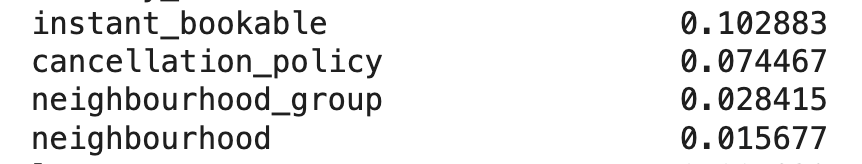

Therefore, we can safely drop the NaN rows in these four columns.

Then we filled important columns like "price", "service_fee", "construction_year", "availability_365", "reviews_per_month" with median in their respective columns, because their values are more distributed and using median will be a good way to avoid too much influence from outliers.


Fill latitude column "lat" and longtitude column "long" with mean, because values are very close and centered in NYC.

We then cleaned certain columns by removing the dollar sign in the "price" and "service_fee" columns, then converting columns "minimum_nights", "number_of_reviews", "review_rate_number", "calculated_host_listings_count" to type of int because we will need numeric values in the upcoming models and analysis.

We also found that some typos existing in the column "neighbourhood_group", like "brookln" should be "Brooklyn", we also correct these typos here.

In [ ]:
df = df.dropna(subset=["instant_bookable", "cancellation_policy", "neighbourhood_group", "neighbourhood"])

# Clean currency columns
def remove_dollar_sign(val):
    if pd.isna(val): return np.nan
    return float(str(val).replace("$", "").replace(",", "").strip())

df["price"] = df["price"].apply(remove_dollar_sign)
df["service_fee"] = df["service_fee"].apply(remove_dollar_sign)

# Fill currency/numerical values with median
df["price"] = df["price"].fillna(df["price"].median())
df["service_fee"] = df["service_fee"].fillna(df["service_fee"].median())

# Fill lat/long with mean (because values are very close and centered in NYC)
df["lat"] = df["lat"].fillna(df["lat"].mean())
df["long"] = df["long"].fillna(df["long"].mean())

# Fill construction year with median year
df["construction_year"] = df["construction_year"].fillna(df["construction_year"].median())

# Fill with median
df["availability_365"] = df["availability_365"].fillna(df["availability_365"].median())
df["reviews_per_month"] = df["reviews_per_month"].fillna(df["reviews_per_month"].median())


columns_to_clean = [
    "minimum_nights",
    "number_of_reviews",
    "review_rate_number",
    "calculated_host_listings_count",
    "construction_year"
]

# Fill with Median and Convert types
for col in columns_to_clean:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value).astype(int)


In [ ]:
# Correct the typos in column "neighbourhood_group"
df.loc[df["neighbourhood_group"].str.lower() == "brookln", "neighbourhood_group"] = "Brooklyn"

In [ ]:
# Check the correctness of "neighbourhood_group"
df["neighbourhood_group"].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

After dealing with NaN values, we checked the missing percentage again in our dataset, and now it contains null, meaning that we no longer have NaN in our dataset.

In [ ]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print("Missing values (%):\n", missing_pct[missing_pct > 0])

Missing values (%):
 Series([], dtype: float64)


In [ ]:
df.isnull().any()

,0
id,False
neighbourhood_group,False
neighbourhood,False
lat,False
long,False
instant_bookable,False
cancellation_policy,False
room_type,False
construction_year,False
price,False


And also we check the shape of the dataset to see how many rows are remained after our cleaning process, it still contains over 10,000 rows, which is good and enough for our analysis.

In [ ]:
df.shape

(101911, 17)

### Column Descriptions (Cleaned Airbnb Dataset)
Let's make a note for what each column represents in our cleaned dataset before we step into the next section of analysis.



Below is a description of each column in the cleaned dataset:

- **id**: Unique identifier for each Airbnb listing.
- **neighbourhood_group**: Broad geographical region or administrative zone the listing is in.
- **neighbourhood**: More specific local area within the neighbourhood group.
- **lat**: Latitude coordinate of the listing location (WGS84 system).
- **long**: Longitude coordinate of the listing location (WGS84 system).
- **instant_bookable**: Whether the listing can be booked instantly (`t` or `f`) without host approval.
- **cancellation_policy**: Type of cancellation policy set by the host (e.g., flexible, moderate, strict).
- **room_type**: Type of space offered (e.g., entire home, private room, shared room, hotel room).
- **construction_year**: The year in which the property was built.
- **price**: Price per night (in local currency).
- **service_fee**: Airbnb service fee associated with the booking.
- **minimum_nights**: Minimum number of nights required for a booking.
- **number_of_reviews**: Total number of reviews the listing has received.
- **reviews_per_month**: Average number of reviews the listing receives per month.
- **review_rate_number**: Average rating score (e.g., out of 5).
- **calculated_host_listings_count**: Number of listings the host has on the platform.
- **availability_365**: Number of days in a year the listing is available for booking.


In [ ]:
df.head()

,id,neighbourhood_group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
0,1001254,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020,966.0,193.0,10,9,0.21,4,6,286.0
1,1002102,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007,142.0,28.0,30,45,0.38,4,2,228.0
2,1002403,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005,620.0,124.0,3,0,0.74,5,1,352.0
3,1002755,Brooklyn,Clinton Hill,40.68514,-73.95976,True,moderate,Entire home/apt,2005,368.0,74.0,30,270,4.64,4,1,322.0
4,1003689,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,2009,204.0,41.0,10,9,0.10,3,1,289.0


### Plotting

In this section, we will check

Bar Charts:
* the distribution of **room types** in all Airbnb offerings, which reveals the most commonly listed accommodation types and helps understand host preferences and guest demand.

* the distribution of **neighborhood groups**, which highlights the geographical concentration of listings across different parts of NYC and reveals which boroughs are most popular for Airbnb.

* the distribution of **cancellation policies**, which gives insight into the flexibility offered by hosts and helps analyze the risk tolerance or policy preferences across the platform.

* the distribution of **construction years** using a line chart, which helps visualize how frequently listings were constructed over time and identify any trends or fluctuations across different years.


Geographical Maps:
* the distribution of **all housings** on a real NYC map, which allows us to spatially visualize the listings' density and coverage, identifying hotspots and underserved areas across the city.

* the distribution of **prices**, which helps assess the overall pricing landscape of Airbnb listings in NYC and detect outliers, pricing clusters, and affordability trends across the city.

Correlation Heat Map:
* the correlation heatmap of **numerical features**, which reveals relationships between variables like reviews, availability, and pricing, and helps identify which metrics are related or independent, aiding in further analysis and feature selection.

In [ ]:
# Function to plot bar chart for a given column_name
def plot_bar_chart(column_name, top_n=10, palette="viridis", angle=45):
    counts = df[column_name].value_counts().nlargest(top_n)
    plt.figure(figsize=(6,3))
    sns.barplot(x=counts.index, y=counts.values, palette=palette)
    plt.xticks(rotation=angle)
    plt.title(f"Top {top_n} most common {column_name}")
    plt.ylabel("Count")
    plt.xlabel(column_name.capitalize())
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# Function to plot line chart for a given column_name
def plot_line_chart(column_name):
    plt.figure(figsize=(6, 3))
    # Convert column to integers before plotting (in case it's float)
    value_counts = df[column_name].dropna().astype(int).value_counts().sort_index()
    plt.plot(value_counts.index, value_counts.values, marker='o', linestyle='--', color='teal')
    plt.title(f"Distribution of {column_name}")
    plt.xlabel(column_name.replace('_', ' ').capitalize())
    plt.ylabel("Count")
    plt.xticks(value_counts.index, rotation=45)  # Ensures clean integer x-axis
    plt.grid(True)
    plt.tight_layout()
    plt.show()

<ipython-input-18-1d1dded3797b>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=palette)


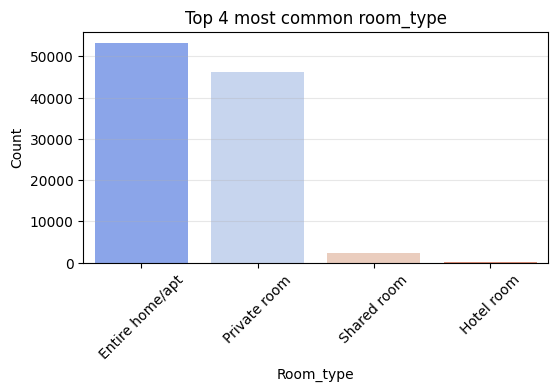

In [ ]:
# Plot Bar Chart for column "room_type, identifying the top 4 most common room types.
plot_bar_chart("room_type", top_n=4, palette="coolwarm")

The chart shows that "Entire home/apt" is by far the most common room type listed on Airbnb, followed by "Private room," indicating a strong preference for private accommodations. In contrast, "Shared room" and "Hotel room" listings are much less common, suggesting limited demand or supply for these options. This distribution highlights that most Airbnb hosts offer full units, likely catering to travelers seeking privacy or longer stays.

<ipython-input-18-1d1dded3797b>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=palette)


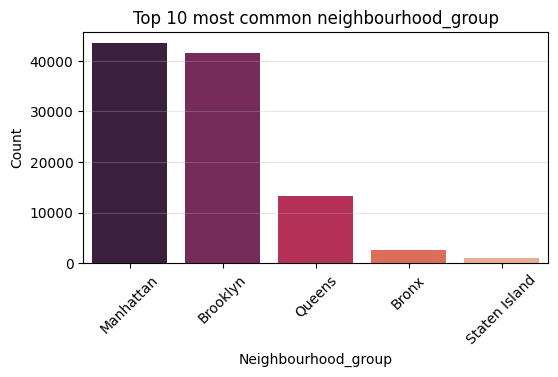

In [ ]:
# Plot Bar Chart for column "neighbourhood_group"
plot_bar_chart("neighbourhood_group", palette="rocket")

The chart illustrates that Manhattan and Brooklyn dominate the Airbnb listings by neighbourhood group, significantly surpassing other boroughs. Queens follows distantly, while the Bronx and Staten Island have relatively few listings. This suggests that the short-term rental market is heavily concentrated in Manhattan and Brooklyn, likely due to higher tourist activity and demand in these areas.


<ipython-input-18-1d1dded3797b>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=palette)


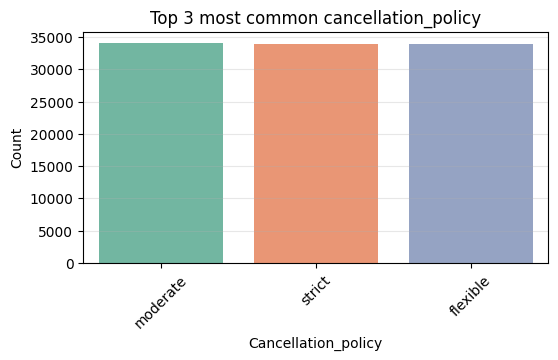

In [ ]:
# Plot Bar Chart for "cancellation_policy", identifying the top 3 most common policies
plot_bar_chart("cancellation_policy", top_n=3, palette="Set2")

The chart shows that the three main cancellation policies—moderate, strict, and flexible—are nearly equally common among Airbnb listings. This indicates that hosts are fairly evenly divided in their preferences for cancellation terms, possibly reflecting a balance between guest flexibility and host protection. No single policy overwhelmingly dominates, suggesting a diverse approach to risk and commitment across hosts.

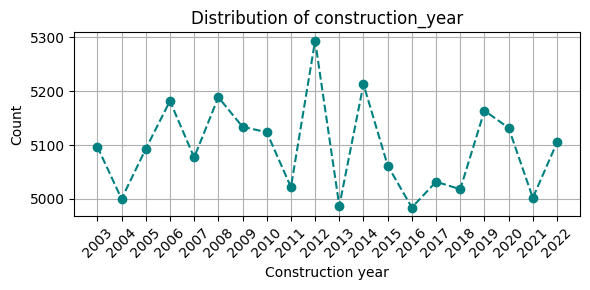

In [ ]:
# Plot Line Chart for column "construction_year"
plot_line_chart("construction_year")

The line chart of `construction_year` reveals a fairly consistent distribution of listings across years, with minor fluctuations. Notable peaks occur around 2012 and 2014, suggesting more properties were constructed or listed from those years. Despite slight dips in certain years like 2013 and 2021, the overall trend indicates a steady stream of new constructions being added to the Airbnb platform over time.

In [ ]:
# Next, we will visualize the locations for all housing on a real NYC map, and also check the locations of popular attractions in NYC.


# ------------------------
# Tourist Attractions Setup
# ------------------------
attractions = {
    1: ("Statue of Liberty", 40.6892, -74.0445),
    2: ("Brooklyn Bridge", 40.7061, -73.9969),
    3: ("World Trade Center", 40.7127, -74.0134),
    4: ("Empire State Building", 40.7484, -73.9857),
    5: ("Times Square", 40.7580, -73.9855),
    6: ("Central Park", 40.7829, -73.9654),
    7: ("Metropolitan Museum", 40.7794, -73.9632),
    8: ("Rockefeller Center", 40.7587, -73.9787),
    9: ("Broadway", 40.7590, -73.9845),
    10: ("The High Line", 40.7480, -74.0048),
}

# Create DataFrame for attractions
attractions_df = pd.DataFrame([
    {"number": num, "name": name, "lat": lat, "lon": lon}
    for num, (name, lat, lon) in attractions.items()
])

# ------------------------
# Combine Data for Plotting
# ------------------------
df_listings = df.copy()
df_listings["type"] = "Listing"
df_listings["text"] = ""  # no tooltip for listings

attractions_df["type"] = "Attraction"
attractions_df["text"] = attractions_df["number"].astype(str) + ". " + attractions_df["name"]

# Rename to match df
attractions_df.rename(columns={"lon": "long"}, inplace=True)

# Merge
combined_df = pd.concat([
    df_listings[["lat", "long", "type", "text"]],
    attractions_df[["lat", "long", "type", "text"]]
])

# ------------------------
# Plotly Map
# ------------------------
fig = px.scatter_mapbox(
    combined_df,
    lat="lat",
    lon="long",
    color="type",
    hover_name="text",
    zoom=10,
    opacity=0.5,
    color_discrete_map={
        "Listing": "darkred",
        "Attraction": "blue"
    }
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0, "t":100, "l":0, "b":0},
    title={
        "text": (
            "Distribution of Airbnb Listings and Major Tourist Attractions in NYC<br>"
            "<span style='font-size:14px; font-weight:normal'>"
            "Hover on the map: red dots show housing prices, blue dots show tourist attractions.<br>"
            "Use the plus (+) and minus (–) buttons on the upper right to zoom in and out of the map."
            "</span>"
        ),
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top"
    },
)


fig.show()


Output hidden; open in https://colab.research.google.com to view.

The map reveals a dense concentration of Airbnb listings throughout New York City, with the heaviest clusters in Manhattan, Brooklyn, and parts of Queens.

* Manhattan stands out with particularly high saturation, indicating its popularity and demand as a central tourist destination.

* Brooklyn also shows significant Airbnb presence, especially in neighborhoods near Manhattan like Williamsburg.

* Listings are more sparsely distributed in the Bronx, Staten Island, and the outer edges of Queens, reflecting either lower tourist activity or stricter housing regulations in those areas.

Overall, the spatial distribution aligns closely with population density and tourist hotspots (in blue spots) in NYC.


In [ ]:
# Comparing price and place using scatter mapbox (color based on price)

fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="long",
    color="price",  # Continuous color scale based on price
    size_max=10,
    opacity=0.4,
    hover_name="neighbourhood",
    hover_data={"price": True, "neighbourhood_group": True, "lat": False, "long": False},
    # color_continuous_scale=px.colors.sequential.PuBuGn,
    color_continuous_scale=px.colors.diverging.RdBu[::-1],  # Red (high) to Blue (low)
    zoom=10,
    title="Airbnb Price Distribution Across NYC"
)

# Map layout and styling
fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r": 0, "t": 100, "l": 0, "b": 0},
    title={
        "text": (
            "Airbnb Price Distribution Across NYC<br>"
            "<span style='font-size:14px; font-weight:normal'>"
            "Hover on the map: red dots show higher housing prices, blue dots show lower housing prices.<br>"
            "Use the plus (+) and minus (–) buttons on the upper right to zoom in and out of the map."
            "</span>"
        ),
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top"
    },
)


fig.show()


Output hidden; open in https://colab.research.google.com to view.

The heatmap of Airbnb listing prices across New York City reveals a clear spatial pattern, with higher-priced listings (shown in red) concentrated in central Manhattan, especially around Midtown and Downtown, which are known for their proximity to major tourist attractions and business districts. In contrast, listings in outer boroughs such as Queens, the Bronx, and parts of Brooklyn tend to be more moderately or lower priced (represented in cooler blue tones).

This geographic pricing disparity highlights how location significantly impacts Airbnb rental costs, with central, high-demand areas commanding premium prices.

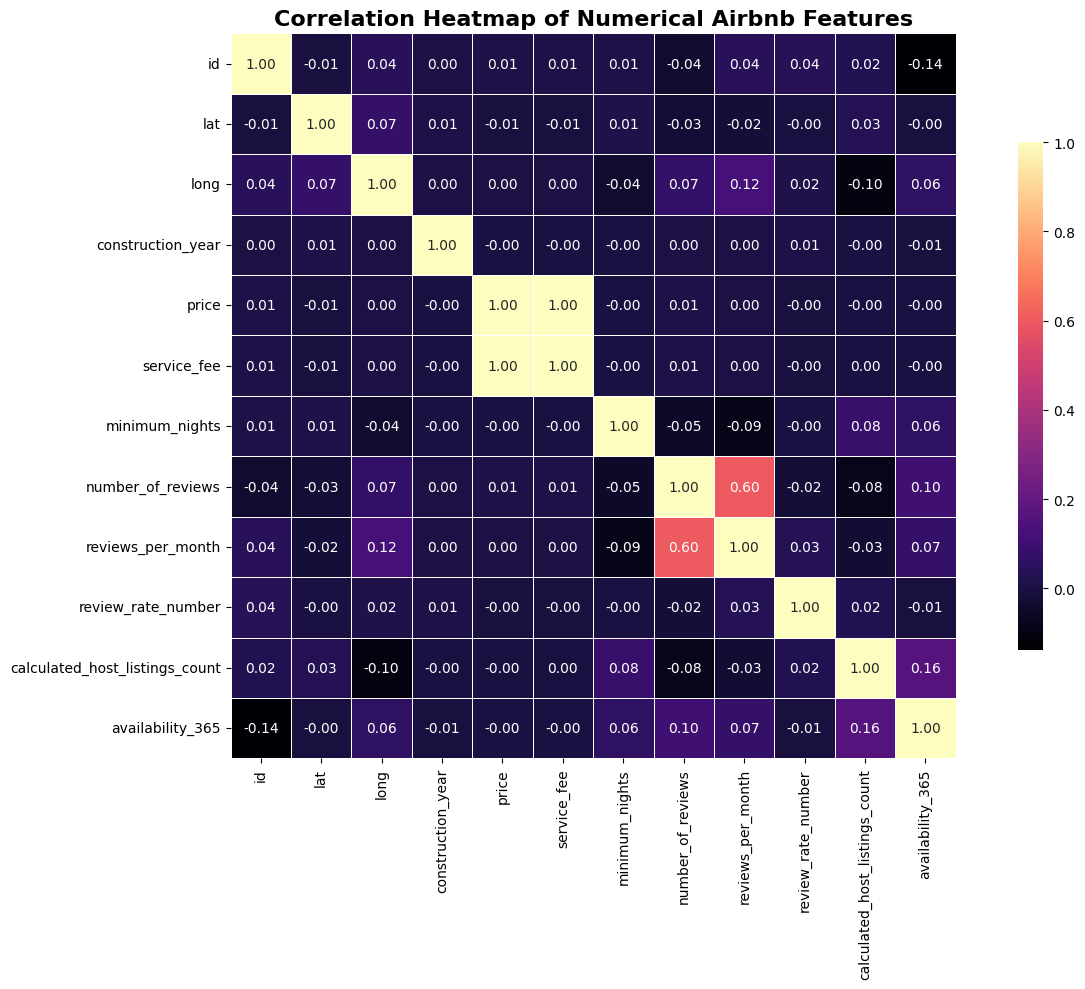

In [ ]:
# Next, we explore the correlation coefficient between numberic columns

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=["float64", "int64"])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",  # or use "coolwarm", "RdBu", "viridis"
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Heatmap of Numerical Airbnb Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


The correlation heatmap reveals that most numerical features in the Airbnb dataset have weak or no linear relationships with one another, suggesting a high degree of independence across variables. The only notable correlation is between `number_of_reviews` and `reviews_per_month` (0.60), which is expected since listings with more reviews tend to receive them consistently. Other features such as `price`, `minimum_nights`, and `availability_365` show very low correlations with any variable, indicating that price patterns and booking behavior are likely influenced by categorical or external contextual factors (like location or room type) rather than internal numerical features.

## Modeling

### Baseline Model (Linear Regression)

Let's first try a simple linear regression (without any tuning) as our baseline model to see how it performs and how we can improve it based on its performance.

In [ ]:
# Apply logarithmic transformation to 'price' to reduce skewness and stabilize variance
# This helps improve clustering performance by normalizing the scale
df['log_price'] = np.log(df['price'])

In [ ]:
target = 'log_price'

In [ ]:
all_features = [
    'neighbourhood_group',  # categorical
    'neighbourhood',        # categorical
    'room_type',           # categorical
    'instant_bookable',     # binary
    'cancellation_policy',  # categorical
    'construction_year',    # numerical
    'minimum_nights',       # numerical
    'number_of_reviews',    # numerical
    'reviews_per_month',    # numerical
    'review_rate_number',   # numerical
    'calculated_host_listings_count',  # numerical
    'availability_365'      # numerical
]

# Split data into features and target
X = df[all_features]
y = df[target]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Preprocessing
categorical_cols = ['neighbourhood_group', 'neighbourhood', 'room_type',
                   'cancellation_policy', 'instant_bookable']
numerical_cols = ['construction_year', 'minimum_nights', 'number_of_reviews',
                 'reviews_per_month', 'review_rate_number',
                 'calculated_host_listings_count', 'availability_365']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

In [ ]:
# Create pipeline with preprocessing and linear regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [ ]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.7f}")
print(f"R-squared: {r2:.7f}")

Root Mean Squared Error: 0.7293662
R-squared: -0.0012959


**Linear Regression Model Assessment:**

RMSE(0.7293682): the average magnitude of the errors in the model's predictions is 0.7293682. In simple terms, the model's predictions are off by about 0.73 on average (in the log-transformed scale of the price).

R²(-0.0013013): A negative R² means the model performs worse than just predicting the mean price for all listings. This indicates the model isn't capturing meaningful patterns.

Now, let's see the detailed coefficient for each feature in the linear model, so that we could have a better understanding of which features might influence listing prices more.

In [ ]:
# Extract coefficients
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_features)

coefficients = model.named_steps['regressor'].coef_
intercept = model.named_steps['regressor'].intercept_

# Create coefficient DataFrame
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})
# Add intercept at the top
coef_df = pd.concat([
    pd.DataFrame({'Feature': ['INTERCEPT'], 'Coefficient': [intercept]}),
    coef_df
], ignore_index=True)

# Get detailed coefficients
pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')

#### Feature Importance

In [ ]:
# Group coefficients by original categorical variables
# Create a dictionary to store aggregated coefficients
coef_dict = defaultdict(list)

# Process each feature and its coefficient
for feature, coef in zip(all_feature_names, coefficients):
    # Check if feature is from one-hot encoding
    if any(f"{cat}_" in feature for cat in categorical_cols):
        # Find which original categorical variable it belongs to
        for cat in categorical_cols:
            if feature.startswith(f"{cat}_"):
                coef_dict[cat].append((feature.replace(f"{cat}_", ""), coef))
                break
    else:
        # Numerical features
        coef_dict[feature].append(("", coef))

# Create a simplified coefficient table
simplified_coefs = []
simplified_coefs.append(("INTERCEPT", intercept))

for feature, values in coef_dict.items():
    if feature in categorical_cols:
        # For categorical variables, calculate average absolute coefficient
        avg_impact = np.mean(np.abs([x[1] for x in values]))
        simplified_coefs.append((feature, avg_impact))
    else:
        # For numerical features
        simplified_coefs.append((feature, values[0][1]))

# Create and display the simplified DataFrame
simplified_df = pd.DataFrame(simplified_coefs, columns=["Feature", "Coefficient"])
print(simplified_df)

                           Feature  Coefficient
0                        INTERCEPT     6.253883
1                construction_year    -0.003944
2                   minimum_nights    -0.002674
3                number_of_reviews     0.003929
4                reviews_per_month    -0.000637
5               review_rate_number     0.002243
6   calculated_host_listings_count     0.003791
7                 availability_365    -0.003384
8              neighbourhood_group     0.015390
9                    neighbourhood     0.132841
10                       room_type     0.039588
11             cancellation_policy     0.000731
12                instant_bookable     0.002961


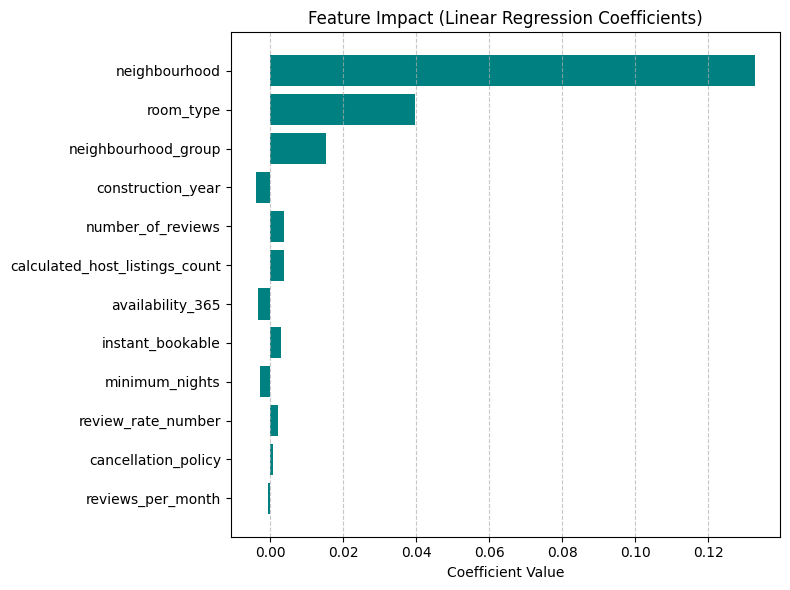

In [ ]:
# Sort simplified_df by absolute coefficient values (excluding intercept)
plot_df = simplified_df[simplified_df["Feature"] != "INTERCEPT"].copy()
plot_df["AbsCoefficient"] = plot_df["Coefficient"].abs()
plot_df.sort_values(by="AbsCoefficient", ascending=True, inplace=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(plot_df["Feature"], plot_df["Coefficient"], color='teal')
plt.xlabel("Coefficient Value")
plt.title("Feature Impact (Linear Regression Coefficients)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Observing the above coefficients, we can see that listing prices appear to be more strongly associated with variables like neighbourhood and room type, as their corresponding coefficients are relatively larger compared to others.

However, since the performance of Linear Regression model wasn't satisfactory, it suggests there exists nonlinear relationships between the features. So we try the following models to capture nonlinear relationships.

### Gradient Boosted Trees

We chose to experiment with the **Gradient Boosted Trees (GBT)** model because it is well-regarded for its ability to capture complex, non-linear relationships in structured data. Unlike simpler models like linear regression, GBT builds trees sequentially, where each new tree focuses on correcting the errors of the previous ones. This iterative refinement process often leads to high predictive performance, especially in datasets with a mix of numerical and categorical variables — a common trait in real-world datasets like Airbnb listings.

However, in our case, Gradient Boosted Trees did not significantly improve model performance. Despite its sophistication, the model's RMSE was only marginally better than the baseline, and its R² remained near zero. This suggests that the structured features in our dataset — such as room type, neighborhood, and reviews — may not be sufficient to capture the nuanced drivers of price variation. A possible limitation of GBT is its sensitivity to noise and irrelevant features, which can dilute its learning signal when the underlying patterns are subtle or influenced by external factors. Additionally, without careful tuning and feature engineering, boosting models can overfit or fail to generalize well. Nonetheless, GBT remains a valuable benchmark due to its flexibility and interpretability.

In [ ]:
# Update preprocessing: remove StandardScaler
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])


In [ ]:
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

# Calculate R²
r_squared = r2_score(y_test, y_pred_gb)

# Print results
print("Gradient Boosted Trees RMSE:", rmse)
print("Gradient Boosted Trees R²:", r_squared)


Gradient Boosted Trees RMSE: 0.727822969769499
Gradient Boosted Trees R²: 0.002936837282136784


**Gradient Boosted Trees Baseline Model Assessment:**

RMSE (0.7278): The average prediction error is about 0.73 in the log-transformed scale of price, which is on par with the Random Forest and linear regression models. It means predictions are off by ~0.73 on average.

R² (0.0029): This means the model explains about 0.29% of the variance in the target variable. While it's slightly better than the linear model (which had negative R²), it's still not meaningfully better than just predicting the mean.

#### Gradient Boosted Trees Model Tuning

We change the n_estimators from 100 to 500, and learning rate from 0.1 to 0.01.

In [ ]:
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('regressor', GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, random_state=42))
])

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

# Calculate R²
r_squared = r2_score(y_test, y_pred_gb)

# Print results
print("Gradient Boosted Trees RMSE:", rmse)
print("Gradient Boosted Trees R²:", r_squared)


Gradient Boosted Trees RMSE: 0.7283720554220833
Gradient Boosted Trees R²: 0.0014318570521058005


**Gradient Boosted Trees with Model Tuning Assessment:**

RMSE (0.7284): Surprisingly, slightly worse than the baseline — there is a small increase in prediction error.

R² (0.0014): Also worse than the baseline model. Tuning in this case didn't improve performance — it slightly degraded it.

This suggests that we should try other models to see if there's any improvement.

#### Feature Importance

In [ ]:
# Get feature names from the preprocessor
onehot_features = gb_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(onehot_features)

# Get feature importances from the regressor
importances = gb_model.named_steps['regressor'].feature_importances_

# Create a DataFrame for easy viewing
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the top 10 features
print(feat_imp_df.head(10))

                            Feature  Importance
3                 reviews_per_month    0.150557
6                  availability_365    0.131147
2                 number_of_reviews    0.111147
1                    minimum_nights    0.094401
0                 construction_year    0.085090
4                review_rate_number    0.047922
178     neighbourhood_Richmond Hill    0.030091
128   neighbourhood_Lighthouse Hill    0.027992
230   neighbourhood_Windsor Terrace    0.021566
5    calculated_host_listings_count    0.018933


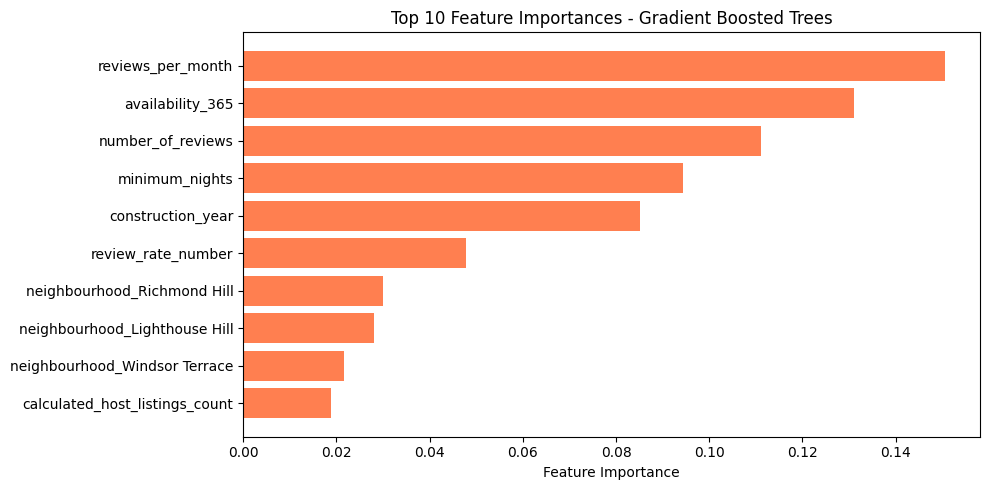

In [ ]:
# Plot top features
plt.figure(figsize=(10, 5))
plt.barh(feat_imp_df.head(10)['Feature'][::-1], feat_imp_df.head(10)['Importance'][::-1], color='coral')
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances - Gradient Boosted Trees")
plt.tight_layout()
plt.show()

- **reviews_per_month** is the top predictor — listings with frequent reviews likely reflect higher demand and consistent bookings.

- **availability_365** also ranks high — full-year availability signals flexibility and maximized booking potential.

- **number_of_reviews** captures historical engagement, another strong indicator of popularity.

- **minimum_nights** and **construction_year **contribute moderately — longer stays may limit guests, and newer listings may be more appealing.

- Specific neighborhoods like **Richmond Hill** and **Lighthouse Hill** add location-based pricing signals.

### Random Forest Regression

Next, We applied the **Random Forest regression** model to predict Airbnb listing prices due to its robustness in handling non-linear relationships and its ability to generalize well without extensive tuning. As an ensemble method, Random Forest reduces overfitting by averaging multiple decision trees and performs reliably on datasets with mixed data types and missing values, which makes it well-suited for real-world data like Airbnb listings.

However, even after hyperparameter tuning, the model only achieved modest improvement — with a slight drop in RMSE and a low R² value — indicating limited ability to explain price variability. This suggests that external factors such as seasonality, aesthetics, or user behavior may play a larger role than structured listing attributes. Additionally, Random Forest is less capable of fine-grained optimization because it builds trees independently and does not prioritize correcting errors from previous trees. Unlike boosting methods like XGBoost, which iteratively focus on hard-to-predict examples, Random Forest lacks this adaptive refinement, making it harder to extract subtle patterns in complex datasets.

In [ ]:
# Pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('regressor', RandomForestRegressor(n_estimators=20,max_depth=10, n_jobs=-1, random_state=42))
])

# Train
rf_model.fit(X_train, y_train)

# Predict using the trained Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate Mean Squared Error
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Calculate RMSE manually
rmse_rf = np.sqrt(mse_rf)

# Calculate R²
r2_rf = r2_score(y_test, y_pred_rf)

# Evaluate the model
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.7268014930021495
Random Forest R²: 0.005733567251834715


**Random Forest Regression Baseline Model Assessment:**

RMSE (0.7268015): The average magnitude of the errors in the model's predictions is approximately 0.73. This means the model's predictions are off by about 0.73 on average, similar to the previous linear regression model, in the log-transformed scale of the price.

R² (0.0057336): The R² value of 0.0057 suggests that the random forest model explains a very small portion of the variability in the data. This value is very close to 0, indicating that while the model is slightly better than the mean-based model, it still isn't capturing meaningful patterns in the data.

#### Random Forest Regression Model Tuning

We changed the n_estimators from 20 to 100, and max_depth from 10 to 15.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Update preprocessing: remove StandardScaler
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('regressor', RandomForestRegressor(n_estimators=100,max_depth=15, n_jobs=-1, random_state=42))
])

# Train
rf_model.fit(X_train, y_train)

# Predict using the trained Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate Mean Squared Error
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Calculate RMSE manually
rmse_rf = np.sqrt(mse_rf)

# Calculate R²
r2_rf = r2_score(y_test, y_pred_rf)

# Evaluate the model
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.7229154939646661
Random Forest R²: 0.01633725846859435


**Random Forest Regression with Model Tuning Assessment:**

RMSE (0.722915): The RMSE is slightly improved (0.72) compared to the baseline, indicating that the tuned random forest model is making slightly more accurate predictions than the baseline model. On average, the error has decreased, though the improvement is small.

R² (0.016337): The R² value of 0.0163 is still very low but shows a slight improvement compared to the baseline (0.0057). This suggests that after tuning, the model is able to explain a slightly higher proportion of the variance in the target variable (price).

#### Feature Importance

In [ ]:
# Feature importance from Random Forest
importances = rf_model.named_steps['regressor'].feature_importances_
feature_names = rf_model.named_steps['preprocessor'].transformers_[0][2] + \
                list(rf_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out())
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df.sort_values(by="Importance", ascending=False).head(10)


,Feature,Importance
3,reviews_per_month,0.150438
6,availability_365,0.144674
2,number_of_reviews,0.121156
0,construction_year,0.105515
1,minimum_nights,0.067034
4,review_rate_number,0.056566
5,calculated_host_listings_count,0.042569
237,room_type_Private room,0.010932
239,cancellation_policy_flexible,0.010305
235,room_type_Entire home/apt,0.010121


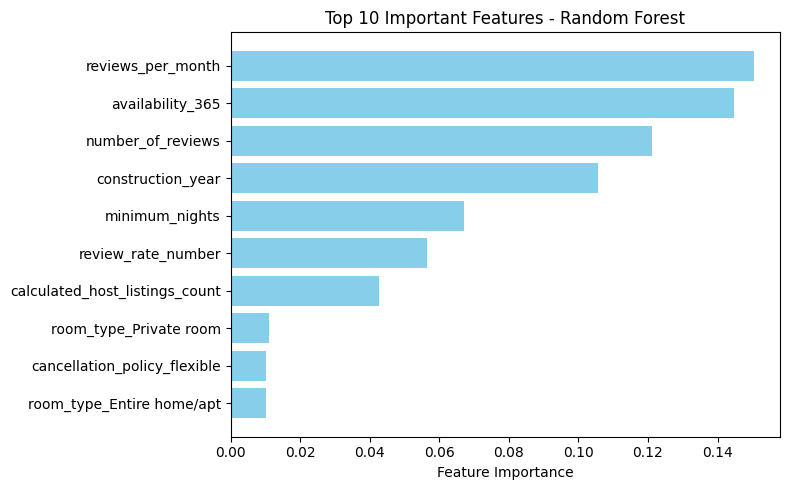

In [ ]:
# Extract feature importances
importances = rf_model.named_steps['regressor'].feature_importances_

# Get numerical + one-hot encoded feature names
num_features = rf_model.named_steps['preprocessor'].transformers_[0][2]
cat_features = list(rf_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out())

feature_names = num_features + cat_features

# Create DataFrame of features and their importance
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort and select top 10 features
top_features = feature_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top 10 Important Features - Random Forest')
plt.tight_layout()
plt.show()


The Random Forest model highlights which features most influence Airbnb pricing:

- Guest activity matters most: **reviews_per_month** and **availability_365** are top predictors, showing that booking frequency and calendar openness strongly affect price.

- Property age matters: **construction_year** plays a moderate role, suggesting older or newer homes impact price tiers.

- Host experience helps: **calculated_host_listings_count** has some influence, likely tied to host professionalism.

- Low impact from room type & policy: **room_type** and **cancellation_policy** contribute little once other factors are considered.

### XGBoost Model with Grid Search

To further improve our model’s performance beyond Random Forest and Gradient Boosted Trees, we introduced the **XGBoost** algorithm—a powerful and efficient implementation of gradient boosting.

XGBoost is well-known for its **ability to handle structured data, reduce overfitting, and deliver higher predictive accuracy** through advanced regularization techniques. We opted to run XGBoost on a **GPU** to significantly accelerate the training and hyperparameter tuning process, especially given the model’s computational intensity during grid or randomized search. Compared to traditional ensemble methods, XGBoost supports more **fine-grained control over model complexity** and **parallelized boosting**, making it particularly effective for exhaustive search over a rich hyperparameter space within a reasonable time frame.

Before running the code in this section, please ***change the runtime type to GPU*** to accelerate the code running time.

In [ ]:
# XGBoost Regressor with GPU support
xgb_reg = xgb.XGBRegressor(
    tree_method='gpu_hist',  # or 'auto' if no GPU
    gpu_id=0,                # GPU ID if using GPU
    objective='reg:squarederror',
    random_state=42
)

# Full pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_reg)
])

# Hyperparameter grid
param_dist = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7, 10],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0]
}

# RandomizedSearchCV for tuning
search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit the model
search.fit(X_train, y_train)

# Evaluate best model
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("✅ Best parameters:", search.best_params_)
print("📉 XGBoost RMSE:", rmse)
print("📊 XGBoost R²:", r2)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[22:50:53] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[22:50:53] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"




✅ Best parameters: {'regressor__subsample': 0.8, 'regressor__n_estimators': 100, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.2, 'regressor__colsample_bytree': 1.0}
📉 XGBoost RMSE: 0.700805604984699
📊 XGBoost R²: 0.07558647869398927


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[22:50:54] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[22:50:54] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.




**XGBoost with Grid Search Assessment:**

RMSE (0.700806): The RMSE is noticeably improved compared to previous models (e.g., 0.7268 for Random Forest), indicating that the tuned XGBoost model is making more accurate predictions on the log-transformed price. The lower error suggests that XGBoost is better able to capture complex, non-linear relationships in the Airbnb dataset.

R² (0.075586): The R² value of 0.0756 represents a further improvement in explanatory power compared to previous models (e.g., 0.0057 for Random Forest). Although still relatively low, this value shows that the XGBoost model explains a larger portion of the variance in listing prices. This makes XGBoost the best-performing model so far in this project, offering modest gains in predictive accuracy while highlighting that other external or unobserved variables may still play a significant role in price determination.



This improvement—though still modest—suggests that while listing prices in the Airbnb dataset are influenced by complex, non-linear relationships, the available features only partially explain the variance. The insights imply that **price alone cannot be fully predicted by listing metadata** (e.g., room type, availability, or reviews), and other latent factors like seasonal trends, listing photos, or textual descriptions may also play a major role.

Nevertheless, XGBoost’s performance demonstrates that **advanced ensemble methods with fine-tuned parameters are more capable of capturing subtle patterns**, especially in high-dimensional structured data. Going forward, enriching the dataset or incorporating external features (e.g., neighborhood desirability scores or time-based pricing) could further enhance prediction accuracy.

#### Feature Importance

In [ ]:
# Get feature names from the pipeline
preprocessor = best_model.named_steps['preprocessor']
numerical_features = preprocessor.transformers_[0][2]
categorical_encoder = preprocessor.transformers_[1][1]
categorical_features = list(categorical_encoder.get_feature_names_out())

all_feature_names = numerical_features + categorical_features

# Get feature importances from XGBoost
xgb_reg = best_model.named_steps['regressor']
importances = xgb_reg.feature_importances_

# Create DataFrame
feature_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)  # Top 10 features

feature_df


,Feature,Importance
60,neighbourhood_Concourse,0.008095
94,neighbourhood_Fort Hamilton,0.007281
59,neighbourhood_Concord,0.007010
232,neighbourhood_Woodlawn,0.006941
200,neighbourhood_St. George,0.006884
43,neighbourhood_Carroll Gardens,0.006674
183,neighbourhood_Roosevelt Island,0.006658
180,neighbourhood_Ridgewood,0.006511
90,neighbourhood_Flushing,0.006470
201,neighbourhood_Stapleton,0.006459


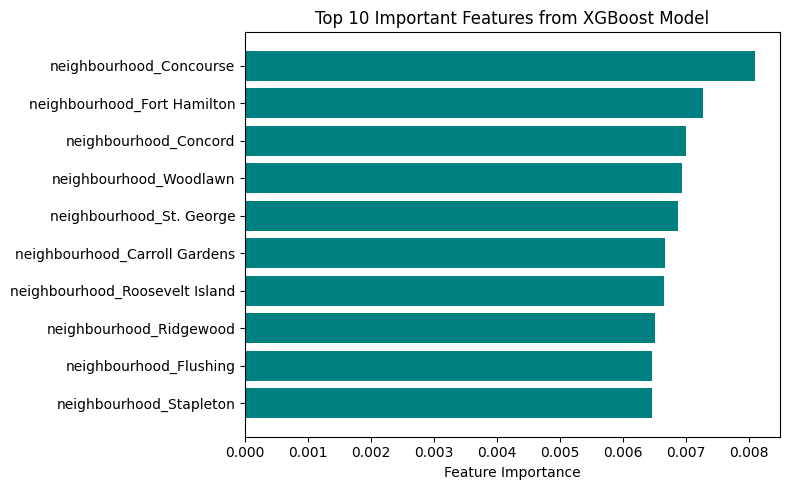

In [ ]:
# Plot
plt.figure(figsize=(8, 5))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='teal')
plt.xlabel('Feature Importance')
plt.title('Top 10 Important Features from XGBoost Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- Neighborhoods drive pricing patterns:
The top features are all encoded neighborhoods, indicating that location — down to the specific neighborhood level — is a major determinant of Airbnb pricing in NYC.

- Less prominent areas show strong influence:
Surprisingly, neighborhoods like **Concourse**, **Fort Hamilton**, and **Woodlawn** appear highly important despite not being among the most tourist-heavy zones. This suggests these areas may have more pricing variability or unique listing characteristics.

- Local micro-trends matter:
The importance of neighborhoods like **Roosevelt Island**, **St. George**, and Flushing shows that micro-location effects (e.g., transit access, amenities, view, borough proximity) are being captured by the model.

### Visualization for model comparison

Let's also create plots to show the improvements based on all the models so far.

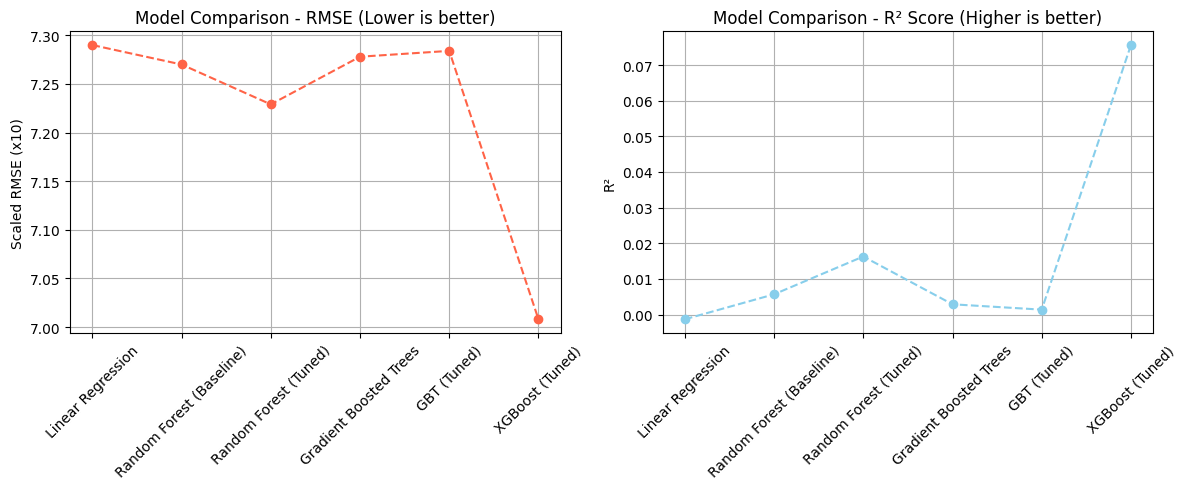

In [ ]:
# Model names
models = [
    "Linear Regression",
    "Random Forest (Baseline)",
    "Random Forest (Tuned)",
    "Gradient Boosted Trees",
    "GBT (Tuned)",
    "XGBoost (Tuned)"
]

# RMSE and R² values
rmse_values = [0.729, 0.727, 0.7229, 0.7278, 0.7284, 0.7008]
r2_values = [-0.0013, 0.0057, 0.0163, 0.0029, 0.0014, 0.0756]

# Slightly scale RMSE for visual clarity
rmse_scaled = [v * 10 for v in rmse_values]

# Set figure
plt.figure(figsize=(12, 5))

# Plot RMSE line chart
plt.subplot(1, 2, 1)
plt.plot(models, rmse_scaled, marker='o', linestyle='--', color='tomato')
plt.title('Model Comparison - RMSE (Lower is better)')
plt.ylabel('Scaled RMSE (x10)')
plt.xticks(rotation=45)
plt.grid(True)

# Plot R² line chart
plt.subplot(1, 2, 2)
plt.plot(models, r2_values, marker='o', linestyle='--', color='skyblue')
plt.title('Model Comparison - R² Score (Higher is better)')
plt.ylabel('R²')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


While all models perform similarly in terms of error, only the tuned XGBoost model shows a noticeable improvement in explanatory power, making it the most effective option in our current analysis.

## Unsupervised learning: K-Means clustering

After evaluating multiple supervised learning models—including linear regression, random forest, gradient boosted trees, and XGBoost model—we found that none of them were able to explain a significant portion of the variation in Airbnb listing prices. Despite hyperparameter tuning, the R² values remained close to zero, indicating limited predictive power. Given these limitations, we decided to explore an unsupervised learning approach—K-Means clustering to uncover hidden patterns in the data that supervised models might have missed.

K-Means clustering allows us to group Airbnb listings based on shared characteristics such as price, reviews, room type, and availability, without relying on a labeled target variable. This method is useful for exploratory analysis, especially when prediction performance is poor, as it can reveal structure or natural groupings in the data. One major advantage is its ability to help identify different "types" of listings in New York City, which could provide actionable insights for segmentation or marketing. However, its limitations include sensitivity to the choice of number of clusters and its assumption of spherical, equally sized clusters—conditions that may not perfectly align with real-world Airbnb data. Nonetheless, clustering offers a valuable alternative lens through which to interpret the dataset.

In [ ]:
# Define the numeric and categorical features to include in clustering
numeric_features = ['minimum_nights', 'number_of_reviews',
                    'review_rate_number',
                    'availability_365', 'log_price']
categorical_features = ['instant_bookable', 'room_type', 'cancellation_policy']

# Create a preprocessor that standardizes numeric features
# and one-hot encodes categorical features (excluding the first category to avoid multicollinearity)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Subset the DataFrame to include only selected features
X_cluster = df[numeric_features + categorical_features]

# Apply the preprocessing pipeline to prepare data for clustering
X_preprocessed = preprocessor.fit_transform(X_cluster)

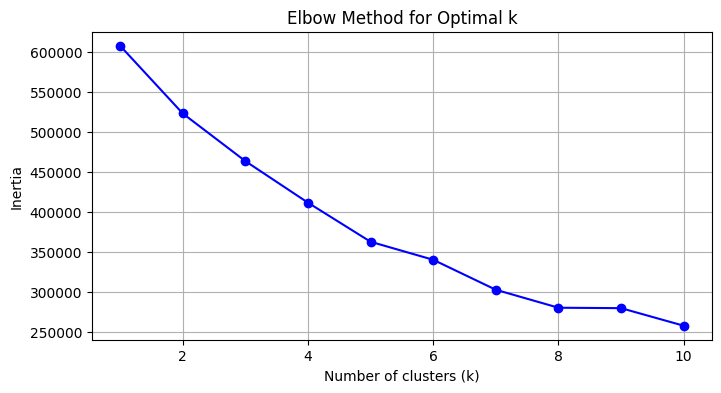

In [ ]:
# Elbow method to choose number of clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_preprocessed)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

From the Elbow plot, we could see that the slop became unstable and decreased less quickly after around 5 clusters. So we chose 5 to be the cluster number.

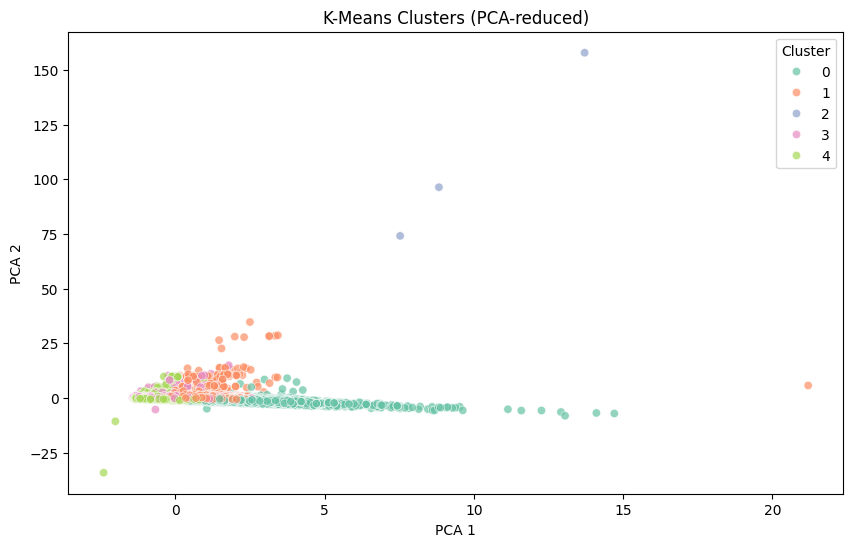

In [ ]:
# Choose k
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_preprocessed)

# Add cluster labels to original dataframe
df['cluster'] = cluster_labels

# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set2', alpha=0.7)
plt.title('K-Means Clusters (PCA-reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

After applying K-Means clustering with k=5, we use PCA to reduce the preprocessed feature space to two dimensions for easier visualization. The scatter plot shows how the data points are grouped into clusters in this reduced space. Each color represents a different cluster, helping us visually assess how well-separated the clusters are.

Let's now see what exactly each cluster looks like in terms of each feature.

We summarize each cluster by computing the average of numeric features and the proportional distribution of categorical features.


In [ ]:
# For numeric features (e.g., minimum_nights, log_price),
# we compute the mean within each cluster to understand the typical values.
df.groupby('cluster')[numeric_features].mean()

,minimum_nights,number_of_reviews,review_rate_number,availability_365,log_price
cluster,,,,,
0,4.539924,165.329618,3.169923,176.437787,6.312560
1,11.897268,17.303977,3.243086,300.623261,6.473613
2,3915.000000,5.000000,2.666667,122.333333,6.631132
3,7.843417,17.923452,3.271842,116.705753,5.038887
4,6.104187,14.856941,3.321309,41.613883,6.569765


In [ ]:
# For categorical features,
# we compute the normalized value counts (i.e., proportions) to see how each category is represented across clusters.
for col in categorical_features:
    display(df.groupby('cluster')[col].value_counts(normalize=True).unstack())


instant_bookable,False,True
cluster,,
0,0.501770,0.498230
1,0.505596,0.494404
2,0.666667,0.333333
3,0.499539,0.500461
4,0.500837,0.499163


room_type,Entire home/apt,Hotel room,Private room,Shared room
cluster,,,,
0,0.537957,0.002884,0.444998,0.014160
1,0.542130,0.001837,0.429057,0.026976
2,0.666667,NaN,0.333333,NaN
3,0.525277,0.000461,0.452266,0.021995
4,0.508131,0.000661,0.471926,0.019282


cancellation_policy,flexible,moderate,strict
cluster,,,
0,0.332241,0.335912,0.331847
1,0.332959,0.331769,0.335272
2,0.666667,0.333333,NaN
3,0.335521,0.333573,0.330906
4,0.330586,0.337461,0.331952


From those above tables, we could make the following observations:

**Cluster 0:** The Balanced Popular Listings
- These are likely well-performing listings that attract many guests for short stays. Their review count is high, indicating popularity and experience. Room types are mixed between entire homes and private rooms. Good candidates for hosts looking to scale or benchmark.

**Cluster 1:** High Availability, Fewer Reviews
- These listings are available almost year-round but aren't booked often. The longer minimum stay requirement may discourage short-term guests. These could be newer or less competitive listings. Possibly used more like long-term rentals or for seasonal guests.

**Cluster 2:** Outlier Cluster (Legacy or Abandoned Listings)
- This is clearly an anomalous or outdated group — the extreme minimum_nights value suggests either a misconfiguration or abandoned listing. Despite high pricing, poor performance and low reviews suggest these listings are likely inactive or mismanaged.

**Cluster 3:** Budget Listings
- These are budget-friendly listings—likely to be private or shared rooms, with limited availability. Possibly casual or part-time hosts catering to short-term, low-cost guests. Best for price-sensitive travelers.

**Cluster 4:** Low Availability, Mid-to-High Pricing
- These listings are rarely available but charge premium prices and have decent reviews. Likely used occasionally—perhaps vacation homes, personal properties, or listings reserved for specific seasons/events.

## Hypothesis Testing

Rather than predicting prices directly, hypothesis testing allows us to examine whether factors like instant bookability or number of reviews have statistically significant effects on listing prices. This method complements our earlier models by providing focused evidence for or against assumed relationships in the Airbnb dataset.

### Test 1:  Do instant bookable listings tend to have higher prices than non-instant bookable ones?

**Null Hypothesis (H₀):**

There is no difference in mean price between instant bookable and non-instant bookable listings.


**Alternative Hypothesis (H₁):**

Instant bookable listings have higher mean prices.

In [ ]:
def bootstrap_mean_diff(data1, data2, n_iterations=10000, seed=42):
    # Set random seed for reproducibility
    np.random.seed(seed)

    # Initialize list to store bootstrap differences
    diffs = []

    # Combine both datasets into one
    combined = np.concatenate([data1, data2])

    # Perform bootstrap resampling
    for _ in range(n_iterations):
        # Resample data1 with replacement from combined
        sample1 = np.random.choice(combined, size=len(data1), replace=True)

        # Resample data2 with replacement from combined
        sample2 = np.random.choice(combined, size=len(data2), replace=True)

        # Compute and store the difference in means
        diffs.append(np.mean(sample1) - np.mean(sample2))

    # Return the array of bootstrap mean differences
    return np.array(diffs)

In [ ]:
# HYPOTHESIS TEST 1: Instant Bookable vs Non-Instant
instant = df[df['instant_bookable'] == True]['log_price'].dropna().values
non_instant = df[df['instant_bookable'] == False]['log_price'].dropna().values

obs_diff_price = np.mean(instant) - np.mean(non_instant)
bootstrap_diffs_price = bootstrap_mean_diff(instant, non_instant)
p_value_price = np.mean(bootstrap_diffs_price >= obs_diff_price)

print("Hypothesis Test 1: Instant Bookable Listings and Price")
print(f"Observed difference in means: {obs_diff_price:.4f}")
print(f"P-value: {p_value_price:.4f}")


Hypothesis Test 1: Instant Bookable Listings and Price
Observed difference in means: 0.0009
P-value: 0.4178


Interpretation:

The p-value is quite high (greater than 0.05), so we fail to reject the null hypothesis.

This means there is no statistically significant difference in the average price between listings that are instant bookable and those that are not.
In practical terms, being "instant bookable" does not appear to affect price meaningfully.

### Test 2: Do listings with more number of reviews tend to have higher prices?

**Null Hypothesis (H₀):**

There is no difference in price between listings with many reviews and few reviews.

**Alternative Hypothesis (H₁):**

Listings with many reviews tend to have higher prices.

In [ ]:
# Drop missing values
df_clean = df[['number_of_reviews', 'log_price']].dropna()

# Step 1: Split into two groups
median_reviews = df_clean['number_of_reviews'].median()
high_review_group = df_clean[df_clean['number_of_reviews'] > median_reviews]['log_price'].values
low_review_group = df_clean[df_clean['number_of_reviews'] <= median_reviews]['log_price'].values

# Step 2: Observed difference
obs_diff = np.mean(high_review_group) - np.mean(low_review_group)

# Step 3: Bootstrapping
def bootstrap_mean_diff(data1, data2, n_iterations=10000, seed=42):
    np.random.seed(seed)
    diffs = []
    combined = np.concatenate([data1, data2])
    for _ in range(n_iterations):
        sample1 = np.random.choice(combined, size=len(data1), replace=True)
        sample2 = np.random.choice(combined, size=len(data2), replace=True)
        diffs.append(np.mean(sample1) - np.mean(sample2))
    return np.array(diffs)

bootstrap_diffs = bootstrap_mean_diff(high_review_group, low_review_group)
p_value = np.mean(bootstrap_diffs >= obs_diff)

# Step 4: Print results
print("Hypothesis Test 2: Number of Reviews and Listing Price")
print(f"Observed difference in log_price: {obs_diff:.4f}")
print(f"P-value: {p_value:.4f}")


Hypothesis Test 2: Number of Reviews and Listing Price
Observed difference in log_price: 0.0078
P-value: 0.0437


Interpretation:

The p-value is below 0.05, so we reject the null hypothesis at the 5% significance level.

This suggests that listings with more reviews tend to have slightly higher prices on average (on the log scale), and this difference is statistically significant, though small.
In practical terms, listings with more reviews may indicate more established or trusted listings, allowing for slightly higher pricing.

## Project Implications & Insights


### Insights


From this project, we draw several key insights:



- Through clustering, we identified five distinct listing personas—such as budget rooms, high-availability listings, and legacy/abandoned listings—offering a blueprint for Airbnb to better segment its host base or tailor onboarding strategies.

- Our hypothesis testing provided actionable insights: listings with more reviews tend to command slightly higher prices, confirming the value of social proof in user behavior.

- Despite trying multiple regression-based models (Linear Regression, Random Forest, Gradient Boosting, XGBoost), model performance remained modest (R² under 0.1), indicating that structured features alone may be insufficient to fully capture the complexity of pricing behavior.











Across all models—Linear Regression, Random Forest, Gradient Boosted Trees, and XGBoost—feature importance results reveal complementary insights:

- Review-based features consistently ranked high (e.g., **reviews_per_month**, **number_of_reviews**), suggesting user engagement is a strong signal for pricing.

- Availability (**availability_365**) emerged as a key predictor in tree-based models, likely reflecting how active listings align with pricing strategies.

- **Neighborhood**-specific one-hot encoded features dominated XGBoost, implying the model captures nuanced local effects more than general listing traits.

### Implications


- Hosts can benefit from our findings by understanding that factors like neighborhood and room type carry the most weight in pricing—information that can guide listing optimization. However, “instant bookable” and cancellation policies, surprisingly, do not have a strong impact on price.


- Travelers can use our map visualizations to identify affordable and high-density areas (e.g., Brooklyn vs. Manhattan) and to choose listings that balance price, availability, and review history.

- Airbnb as a platform could explore using cluster-based personas to recommend pricing strategies or marketing tactics to hosts, particularly for underperforming segments like high-availability but low-review listings.




##Limitations & Future Work

### Limitations




While our project explored a variety of modeling approaches, we encountered several limitations that impacted overall model performance:

- **Low Predictive Power**: Even after hyperparameter tuning, models such as Random Forest, Gradient Boosted Trees, and XGBoost achieved low R² values (mostly under 0.08), indicating limited explanatory strength for price variance.

- **Feature Granularity**: Many structured variables (e.g. room type or neighborhood) may not fully capture listing quality, aesthetics, or host responsiveness, which could explain the weak model generalizability.

- **Data limitations**: Important variables such as listing photos, seasonal trends, guest behavior, and subjective listing quality are not captured in the dataset, yet they likely impact pricing significantly.



### Future Work



To address these limitations and build on our findings, future work could involve several key directions:

- **Use NLP and Computer Vision**: Extract features from listing descriptions or images to capture subjective quality and design elements not available in structured form.
- **Add Time-Sensitive Features**: Include variables like seasonality, booking lead time, and time of year to model dynamic pricing behaviors.
- **Enrich Location Data**: Integrate external geospatial data, such as distance to public transit, local amenities, or tourist attractions, to better contextualize price differences.
- **Try Causal Methods**: Move beyond prediction to understand cause-effect relationships—e.g., whether being instant bookable causes higher pricing—using techniques like instrumental variables or matching.
- **Segment Listings for Specialized Models**: Consider clustering listings into different segments (e.g., by borough or room type) and training separate models for each segment to improve performance within narrower domains.

By expanding both the scope of features and the depth of analysis, future iterations of this work can move closer to uncovering what truly drives Airbnb pricing and availability in New York City.